# House Price Prediction
**Internship Project — Week 1**

This notebook loads, cleans, and explores a housing dataset, builds Linear Regression and Random Forest models to predict house price, evaluates them, visualizes key relationships, and summarizes the findings.

In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
import os
os.makedirs('charts', exist_ok=True)

## Task 1 — Data Loading & Exploration

In [105]:
df = pd.read_csv('Housing-xylofy.csv')
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [106]:
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')

Rows: 545, Columns: 13


In [107]:
print('Target column: price')
feature_cols = [c for c in df.columns if c != 'price']
print('Feature columns:', feature_cols)

Target column: price
Feature columns: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [108]:
print('Missing values per column:')
df.isnull().sum()

Missing values per column:


price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

## Task 2 — Data Cleaning

In [109]:
# Duplicate rows
n_dupes = df.duplicated().sum()
print(f'Duplicate rows found: {n_dupes}')

Duplicate rows found: 0


In [110]:
# No missing or duplicated records found

In [111]:
# Convert categorical yes/no and furnishingstatus columns into numeric form via one-hot encoding
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

binary_cols = [c for c in cat_cols if set(df[c].unique()) <= {'yes', 'no'}]
for c in binary_cols:
    df[c] = df[c].map({'yes': 1, 'no': 0})

df_clean = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)
df_clean.columns = [c.replace(' ', '_') for c in df_clean.columns]
df_clean.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


In [112]:
# All remaining columns are meaningful numeric predictors of price - keep them all

## Task 3 — Model Building

In [113]:
x = df_clean.drop(columns=['price'])
y = df_clean['price']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)
print(f'Train size: {x_train.shape[0]} rows | Test size: {x_test.shape[0]} rows')

Train size: 436 rows | Test size: 109 rows


In [114]:
# --- Linear Regression ---
lin_model = LinearRegression()
lin_model.fit(x_train, y_train)
lin_preds = lin_model.predict(x_test)

lin_mae = mean_absolute_error(y_test, lin_preds)
lin_rmse = mean_squared_error(y_test, lin_preds) ** 0.5
lin_r2 = r2_score(y_test, lin_preds)

print('Linear Regression performance:')
print(f'  MAE  : {lin_mae:,.0f}')
print(f'  RMSE : {lin_rmse:,.0f}')
print(f'  R2   : {lin_r2:.3f}')

Linear Regression performance:
  MAE  : 970,043
  RMSE : 1,324,507
  R2   : 0.653


In [115]:
# --- Random Forest Regressor ---
rf_model = RandomForestRegressor(n_estimators=500, random_state=40)
rf_model.fit(x_train, y_train)
rf_preds = rf_model.predict(x_test)

rf_mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = mean_squared_error(y_test, rf_preds) ** 0.5
rf_r2 = r2_score(y_test, rf_preds)

print('Random Forest performance:')
print(f'  MAE  : {rf_mae:,.0f}')
print(f'  RMSE : {rf_rmse:,.0f}')
print(f'  R2   : {rf_r2:.3f}')

Random Forest performance:
  MAE  : 1,007,865
  RMSE : 1,390,260
  R2   : 0.618


In [116]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [lin_mae, rf_mae],
    'RMSE': [lin_rmse, rf_rmse],
    'R2 Score': [lin_r2, rf_r2]
})
comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.007865e+06,1.390260e+06,0.617609


## Task 4 — Visualization

### Chart 1: Distribution of House Prices

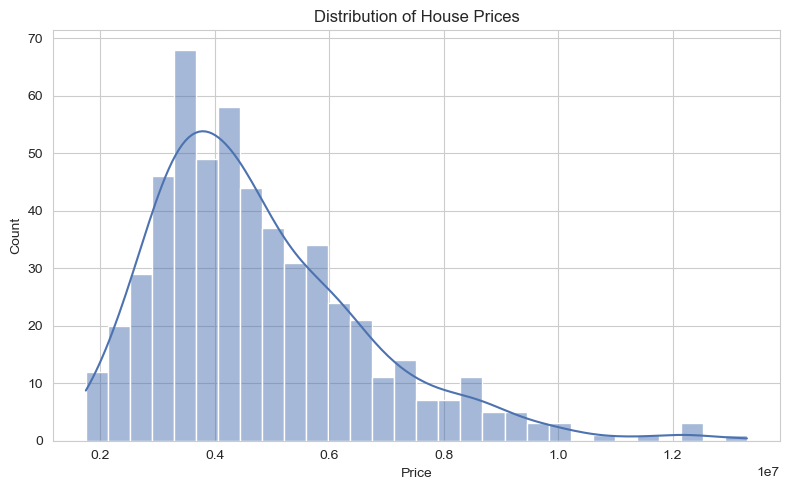

In [117]:
plt.figure(figsize=(8, 5))
sns.histplot(df_clean['price'], bins=30, kde=True, color='#4C72B0')
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('charts/chart1_price_distribution.png', dpi=150)
plt.show()

### Chart 2: Correlation Heatmap

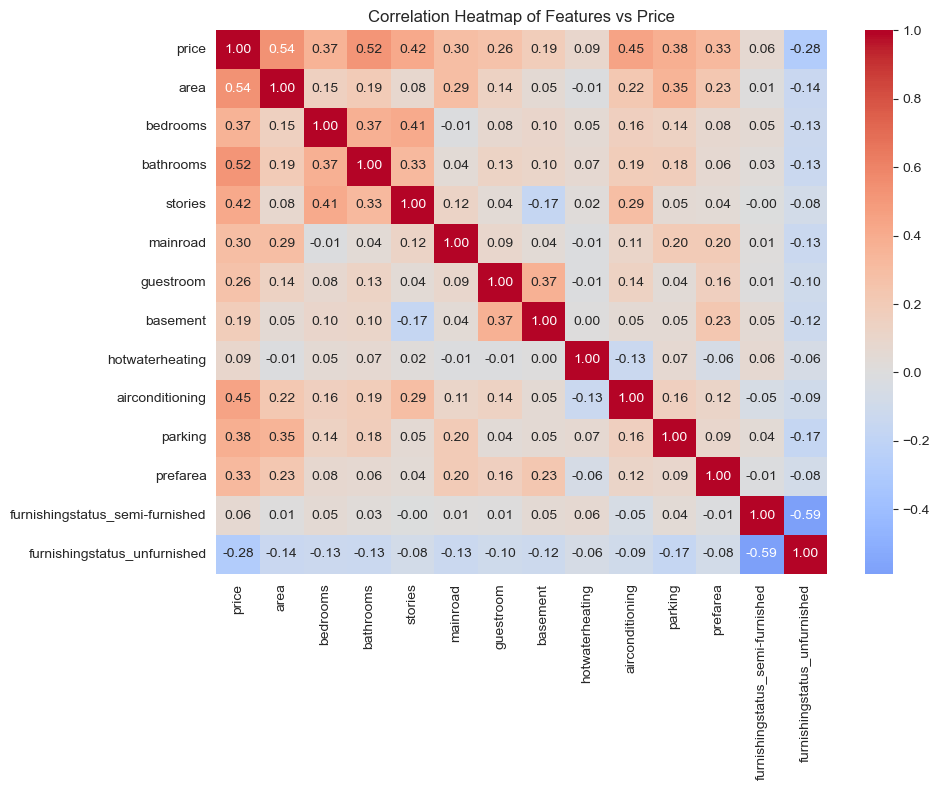

In [118]:
plt.figure(figsize=(10, 8))
corr = df_clean.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Features vs Price')
plt.tight_layout()
plt.savefig('charts/chart2_correlation_heatmap.png', dpi=150)
plt.show()

In [119]:
print('Correlation of each feature with price, sorted:')
corr['price'].drop('price').sort_values(ascending=False)

Correlation of each feature with price, sorted:


area                               0.535997
bathrooms                          0.517545
airconditioning                    0.452954
stories                            0.420712
parking                            0.384394
bedrooms                           0.366494
prefarea                           0.329777
mainroad                           0.296898
guestroom                          0.255517
basement                           0.187057
hotwaterheating                    0.093073
furnishingstatus_semi-furnished    0.063656
furnishingstatus_unfurnished      -0.280587
Name: price, dtype: float64

### Chart 3: Actual vs Predicted Price (Random Forest)

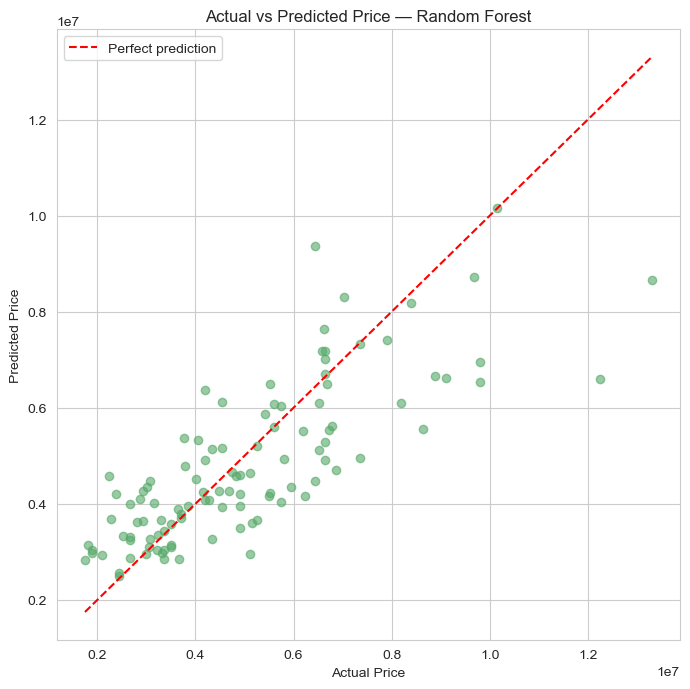

In [120]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, rf_preds, alpha=0.6, color='#55A868')
lims = [min(y_test.min(), rf_preds.min()), max(y_test.max(), rf_preds.max())]
plt.plot(lims, lims, 'r--', label='Perfect prediction')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Price — Random Forest')
plt.legend()
plt.tight_layout()
plt.savefig('charts/chart3_actual_vs_predicted.png', dpi=150)
plt.show()

In [121]:
feat_importance = pd.Series(rf_model.feature_importances_, index=x.columns)
feat_importance.sort_values(ascending=False)

area                               0.467463
bathrooms                          0.153088
parking                            0.058047
airconditioning                    0.057696
stories                            0.055249
bedrooms                           0.047087
furnishingstatus_unfurnished       0.037353
basement                           0.034620
prefarea                           0.029846
hotwaterheating                    0.020785
guestroom                          0.015652
furnishingstatus_semi-furnished    0.012990
mainroad                           0.010124
dtype: float64

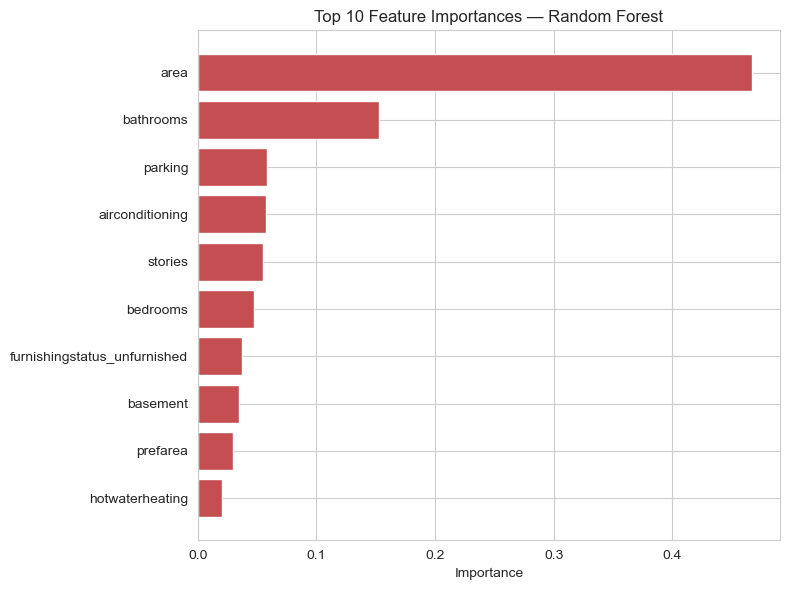

In [122]:
plt.figure(figsize=(8, 6))
top_features = feat_importance.sort_values(ascending=True).tail(10)
plt.barh(top_features.index, top_features.values, color='#C44E52')
plt.xlabel('Importance')
plt.title('Top 10 Feature Importances — Random Forest')
plt.tight_layout()
plt.savefig('charts/chart4_feature_importance.png', dpi=150)
plt.show()

## Task 5 — Insights & Summary

**Which features influence house price the most?** `area` and `bathrooms` are the strongest 
predictors of price, with correlations of 0.54 and 0.52 respectively, followed by 
`airconditioning` (0.45), `stories` (0.42), and `parking` (0.38). The Random Forest's feature 
importance scores back this up — area alone accounts for about 46% of its importance, 
with bathrooms a distant second at 15%. Interestingly, `furnishingstatus_unfurnished` shows 
a notably negative correlation (-0.28), meaning unfurnished homes tend to sell for 
meaningfully less than `furnished` or `semi-furnished` ones.

**How accurate was the model, in plain terms?** The Linear Regression model explains about 
65% of the variation in house price (R² = 0.653), with an average prediction error (MAE) 
of roughly ₹970,000 — about 10-12% of a typical house price in this dataset. Random 
Forest performed slightly worse here (R² = 0.621), which was a bit unexpected since 
ensemble models usually capture non-linear patterns better; with only 545 rows total 
(109 in the test set), there may not be enough data for Random Forest to find patterns 
beyond what the simpler linear model already captures.

**What was surprising in the data?** Hot water heating barely affected price at all 
(correlation of just 0.09) despite being the kind of feature often advertised as a 
selling point, while whether a home was unfurnished mattered more than several physical 
attributes like number of bedrooms.

**Recommendation for a real estate business:** Since area and bathroom count drive the 
majority of price, these should anchor any pricing model or listing strategy. But the 
furnishing-status effect is worth acting on too — staging or lightly furnishing an 
otherwise-unfurnished property before listing could be a low-cost way to lift its 
perceived (and actual) sale price.